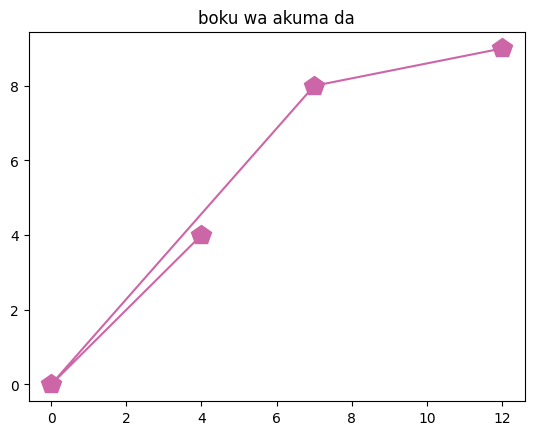

In [1]:
import matplotlib.pyplot as tu
import numpy as np

x=np.array([12,7,0,4])
y=np.array([9,8,0,4])

tu.title('boku wa akuma da')


tu.plot(x, y, marker='p', markersize=15, markerfacecolor='#cc66a7', markeredgecolor='#cc66a7', color='#cc66a7')
tu.show()

In [2]:
import gspread

In [3]:
gc = gspread.service_account(filename='service_account.json')
sheets = gc.open('Đơn hàng Laptop')
ws = sheets.worksheet('Tháng 12/2025')

data = ws.get_all_values()

In [4]:
import pandas as pd 


In [5]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [6]:
df = pd.DataFrame(data[1:], columns=data[0])

df['Chuyển khoản'] = pd.to_numeric(df['Chuyển khoản'], errors='coerce').fillna(0)
df['COD'] = pd.to_numeric(df['COD'], errors='coerce').fillna(0)
df = df[df['Ngày bán'].astype(str).str.strip() != ''] 
df = df.dropna(subset=['Ngày bán'])

df

,STT,Ngày bán,Người mua,Tên máy,Mã máy,COD,Chuyển khoản,,Khách mới,,
0,1,2/12,Văn trung,Dell 3301,LAP 2605,0.0,2300.0,Ckhoan ok - tiền ship con 8790,FALSE,,
1,2,2/12,Văn trung,Dell 7380,S1011,0.0,3555.0,,FALSE,,
2,3,2/12,Văn trung,Dell 7390,S1516,0.0,3000.0,,FALSE,,
3,4,1/12,Nhã,Dell 5567,S1827,0.0,2900.0,Ckhoan ok,FALSE,,
4,5,1/12,Nhã,,S2424,0.0,2900.0,,FALSE,,
5,6,1/12,Nhã,Dell 3380,S2531,0.0,2111.0,,FALSE,,
6,7,3/12,Huyền linh,Dell 7300,S1896,0.0,4200.0,Ckhoan ok,FALSE,,
7,8,3/12,Huyền linh,hp g3,S2309,0.0,3456.0,,FALSE,,Nhật
8,9,3/12,Huyền linh,x360,LAP2635,0.0,3600.0,,FALSE,,Chiến
9,10,3/12,Huyền linh,hp au,LAP2642,0.0,2500.0,,FALSE,,Nam


In [7]:
df_result = df.groupby('Ngày bán')[['Chuyển khoản', 'COD']].sum()

In [8]:
import numpy


In [9]:
x = numpy.array(df_result.index)
y1 = numpy.array(df_result['Chuyển khoản'])
y2 = numpy.array(df_result['COD'])


In [10]:
%matplotlib inline
import matplotlib.pyplot as plt

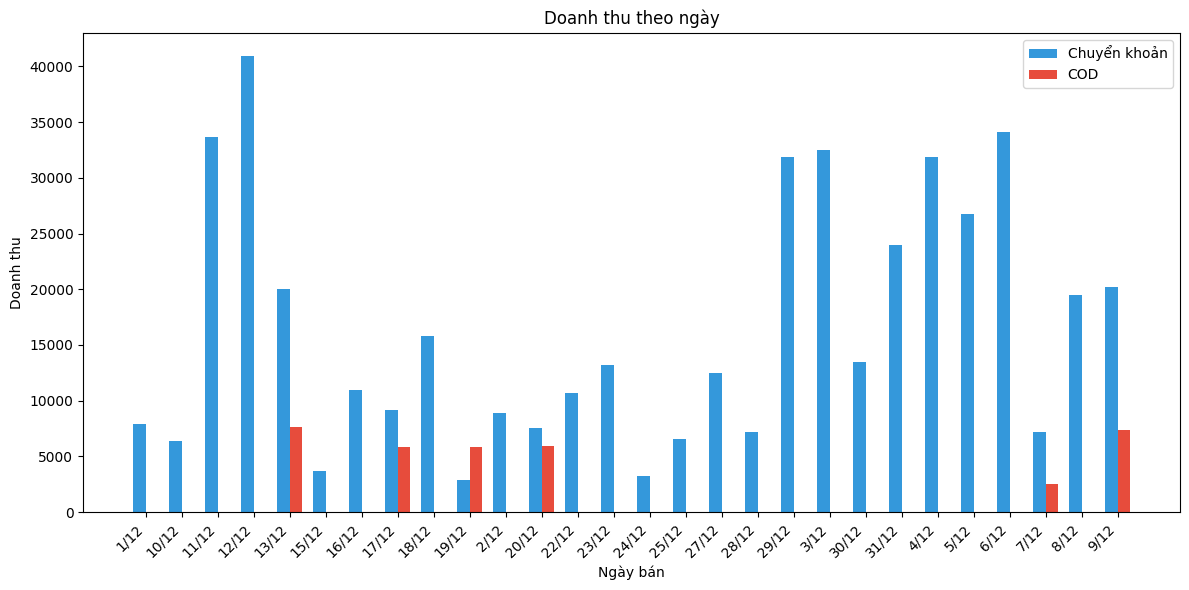

In [11]:
import numpy as np

x_pos = np.arange(len(x))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x_pos - width/2, y1, width, label='Chuyển khoản', color='#3498db')
bars2 = ax.bar(x_pos + width/2, y2, width, label='COD', color='#e74c3c')

ax.set_xlabel('Ngày bán')
ax.set_ylabel('Doanh thu')
ax.set_title('Doanh thu theo ngày')
ax.set_xticks(x_pos)
ax.set_xticklabels(x, rotation=45, ha='right')
ax.legend()



plt.tight_layout()
